In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import skew, kurtosis, pearsonr

In [55]:
DATA_PATH = "../data/brainrot.csv"
TARGET = 'brain_rot_index'

In [56]:
df = pd.read_csv(DATA_PATH)
print(f"Shape: {df.shape}")
print(f"Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")
df.head()

Shape: (500000, 48)
Rows: 500,000  |  Columns: 48


,student_id,country,development_level,poverty_rate_percent,internet_infrastructure_index,average_internet_speed_mbps,age,gender,urban_rural,family_income_level,...,ads_viewed_per_day,ads_clicked_per_week,impulse_purchase_score,digital_spending_per_month,cyberbullying_exposure,adult_content_exposure,digital_addiction_score,wellbeing_index,academic_risk_score,financial_risk_score
0,1,Qatar,Developing,16.30,54.93,27.19,21,Male,Rural,High,...,38.699484,3.119569,3.681066,79.508194,No,No,8.179932,66.662166,0.0,26.516722
1,2,USA,Developed,8.75,94.39,85.34,25,Male,Urban,Middle,...,157.400429,18.358090,6.538867,73.452464,No,Yes,22.073122,43.892278,0.0,39.257741
2,3,Mexico,Developing,23.64,47.24,73.55,18,Female,Urban,Low,...,79.603536,11.758299,5.150660,35.753069,No,No,12.591830,65.484625,0.0,47.542155
3,4,Canada,Developed,14.51,90.50,188.19,25,Male,Urban,Middle,...,69.318324,7.906197,3.195383,47.607487,No,Yes,8.008238,57.909392,0.0,23.436122
4,5,Sri Lanka,Underdeveloped,62.28,36.84,11.02,15,Other,Rural,Middle,...,144.019899,19.427839,7.180234,82.941313,No,No,21.551334,53.686356,0.0,47.308493


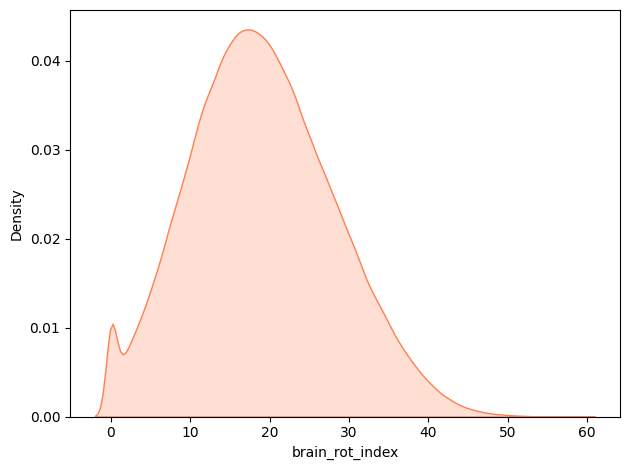

Skewness  : 0.2478
Kurtosis  : -0.2260
Mean      : 19.0278
Std       : 9.0733
Min / Max : 0.0000 / 59.0039


In [57]:
sns.kdeplot(df[TARGET].dropna(), fill=True, color='coral')

plt.tight_layout()
plt.show()

print(f"Skewness  : {skew(df[TARGET].dropna()):.4f}")
print(f"Kurtosis  : {kurtosis(df[TARGET].dropna()):.4f}")
print(f"Mean      : {df[TARGET].mean():.4f}")
print(f"Std       : {df[TARGET].std():.4f}")
print(f"Min / Max : {df[TARGET].min():.4f} / {df[TARGET].max():.4f}")

                 missing_count  missing_pct
field_of_study          247349        49.47
brain_rot_level           6262         1.25


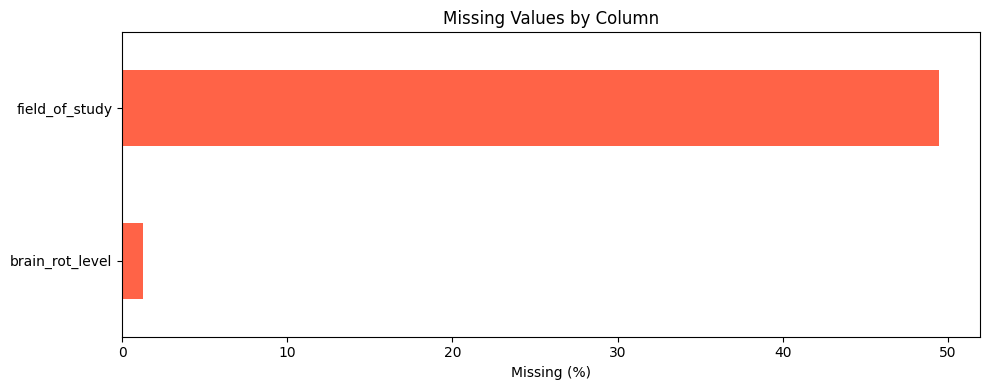

In [58]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_df = missing_df[missing_df['missing_count'] > 0]

if missing_df.empty:
    print("No missing values found in the dataset.")
else:
    print(missing_df)
    fig, ax = plt.subplots(figsize=(10, max(4, len(missing_df) * 0.4)))
    missing_df['missing_pct'].sort_values().plot(kind='barh', ax=ax, color='tomato')
    ax.set_xlabel('Missing (%)')
    ax.set_title('Missing Values by Column')
    plt.tight_layout()
    plt.show()

In [59]:
drop_cols = [
        "academic_risk_score",
        "financial_risk_score",
        "wellbeing_index",
        # Highly correlated country-level columns
        "late_night_score",
        "country",
        "poverty_rate_percent",
        "internet_infrastructure_index",
        "brain_rot_level",          # derived from brain_rot_index
        # Identified as high-risk columns with unrealistic zeros
        "attention_span_minutes",
        "productivity_score",
        "impulse_purchase_score",
        "digital_addiction_score",
        "academic_motivation",
        # Content-hour columns dropped for accuracy / correlation reasons
        "news_content_hours",
        "entertainment_content_hours",
        "education_content_hours",
        # Dropped for completeness (>50 % null)
        "field_of_study",
    ]
existing = [c for c in drop_cols if c in df.columns]
df = df.drop(columns=existing)

In [60]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

Highly skewed features:
average_internet_speed_mbps    1.128168
posts_created_per_week         0.846152
digital_spending_per_month     0.823077
comments_written_per_day       0.795149
likes_given_per_day            0.687944
short_video_hours              0.620698
dtype: float64


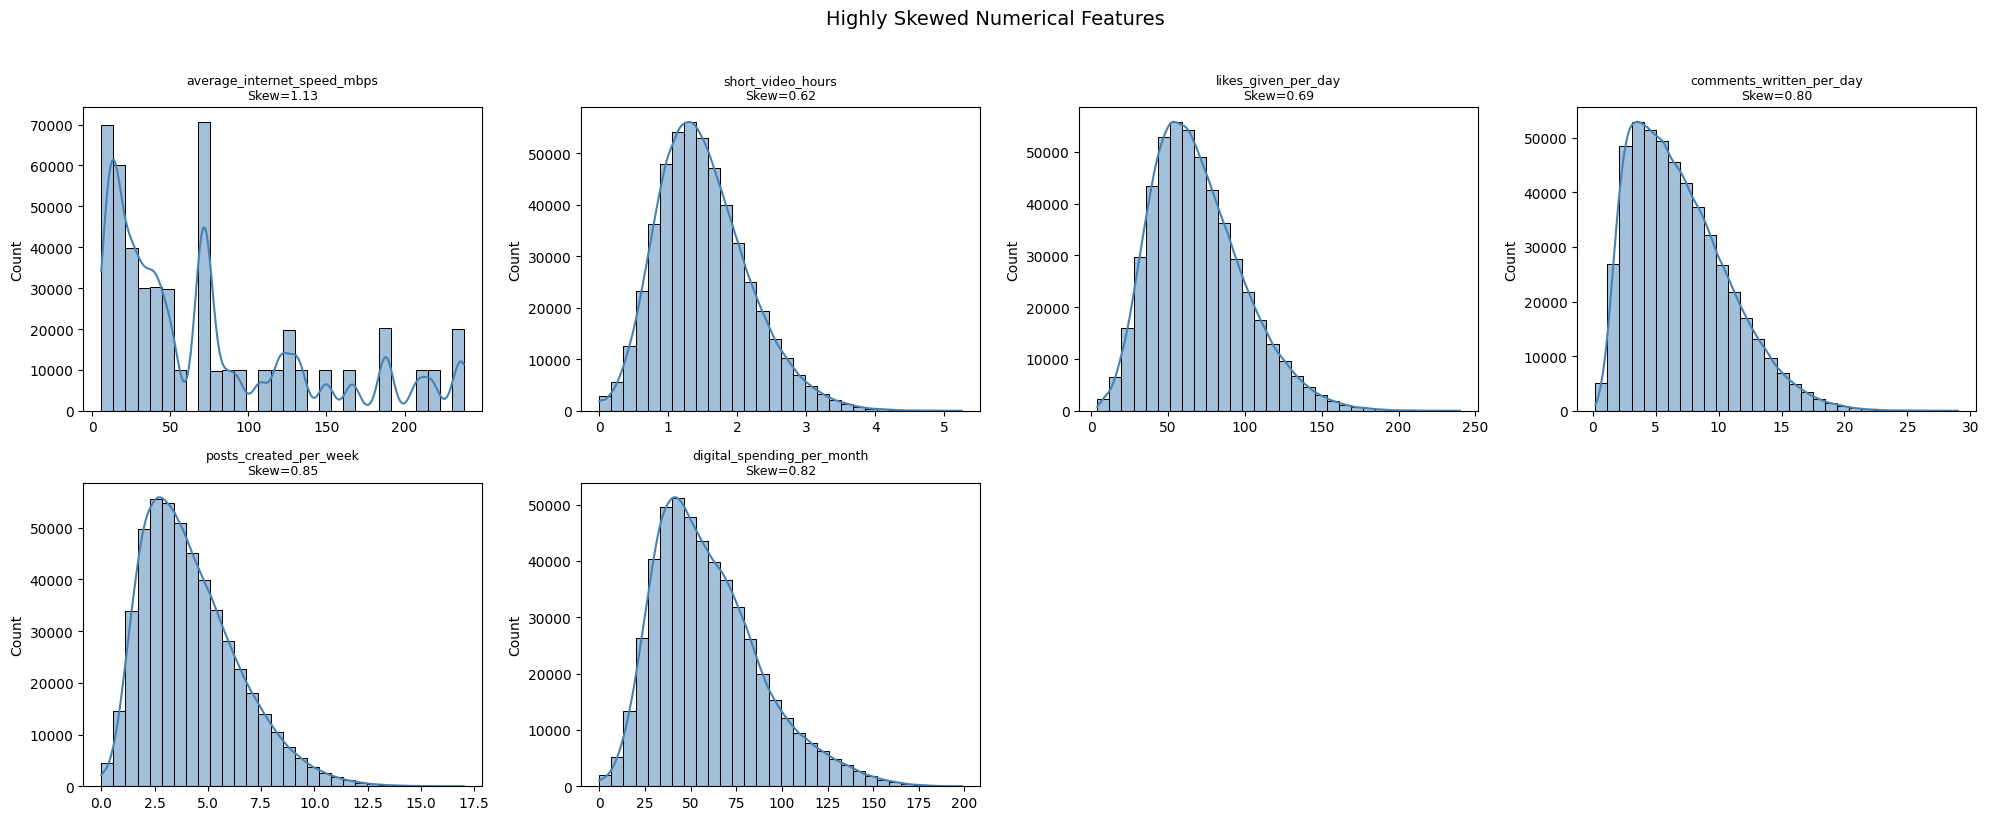

In [71]:
plot_cols = [c for c in num_cols if c not in ['student_id', TARGET]]

skew_vals = df[plot_cols].skew(numeric_only=True)

# Keep only highly skewed features
high_skew_cols = skew_vals[abs(skew_vals) > 0.6].index.tolist()

print("Highly skewed features:")
print(skew_vals[high_skew_cols].sort_values(key=abs, ascending=False))

n = len(high_skew_cols)
ncols = 4
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()

for i, col in enumerate(high_skew_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i], color='steelblue', bins=30)
    axes[i].set_title(f"{col}\nSkew={skew_vals[col]:.2f}", fontsize=9)
    axes[i].set_xlabel("")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Highly Skewed Numerical Features", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [62]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f"Categorical columns ({len(cat_cols)}): {cat_cols}")

Categorical columns (9): ['development_level', 'gender', 'urban_rural', 'family_income_level', 'device_access', 'education_level', 'late_night_usage', 'cyberbullying_exposure', 'adult_content_exposure']


C:\Users\ASM EL Masrya\AppData\Local\Temp\ipykernel_12860\4093098337.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns.tolist()


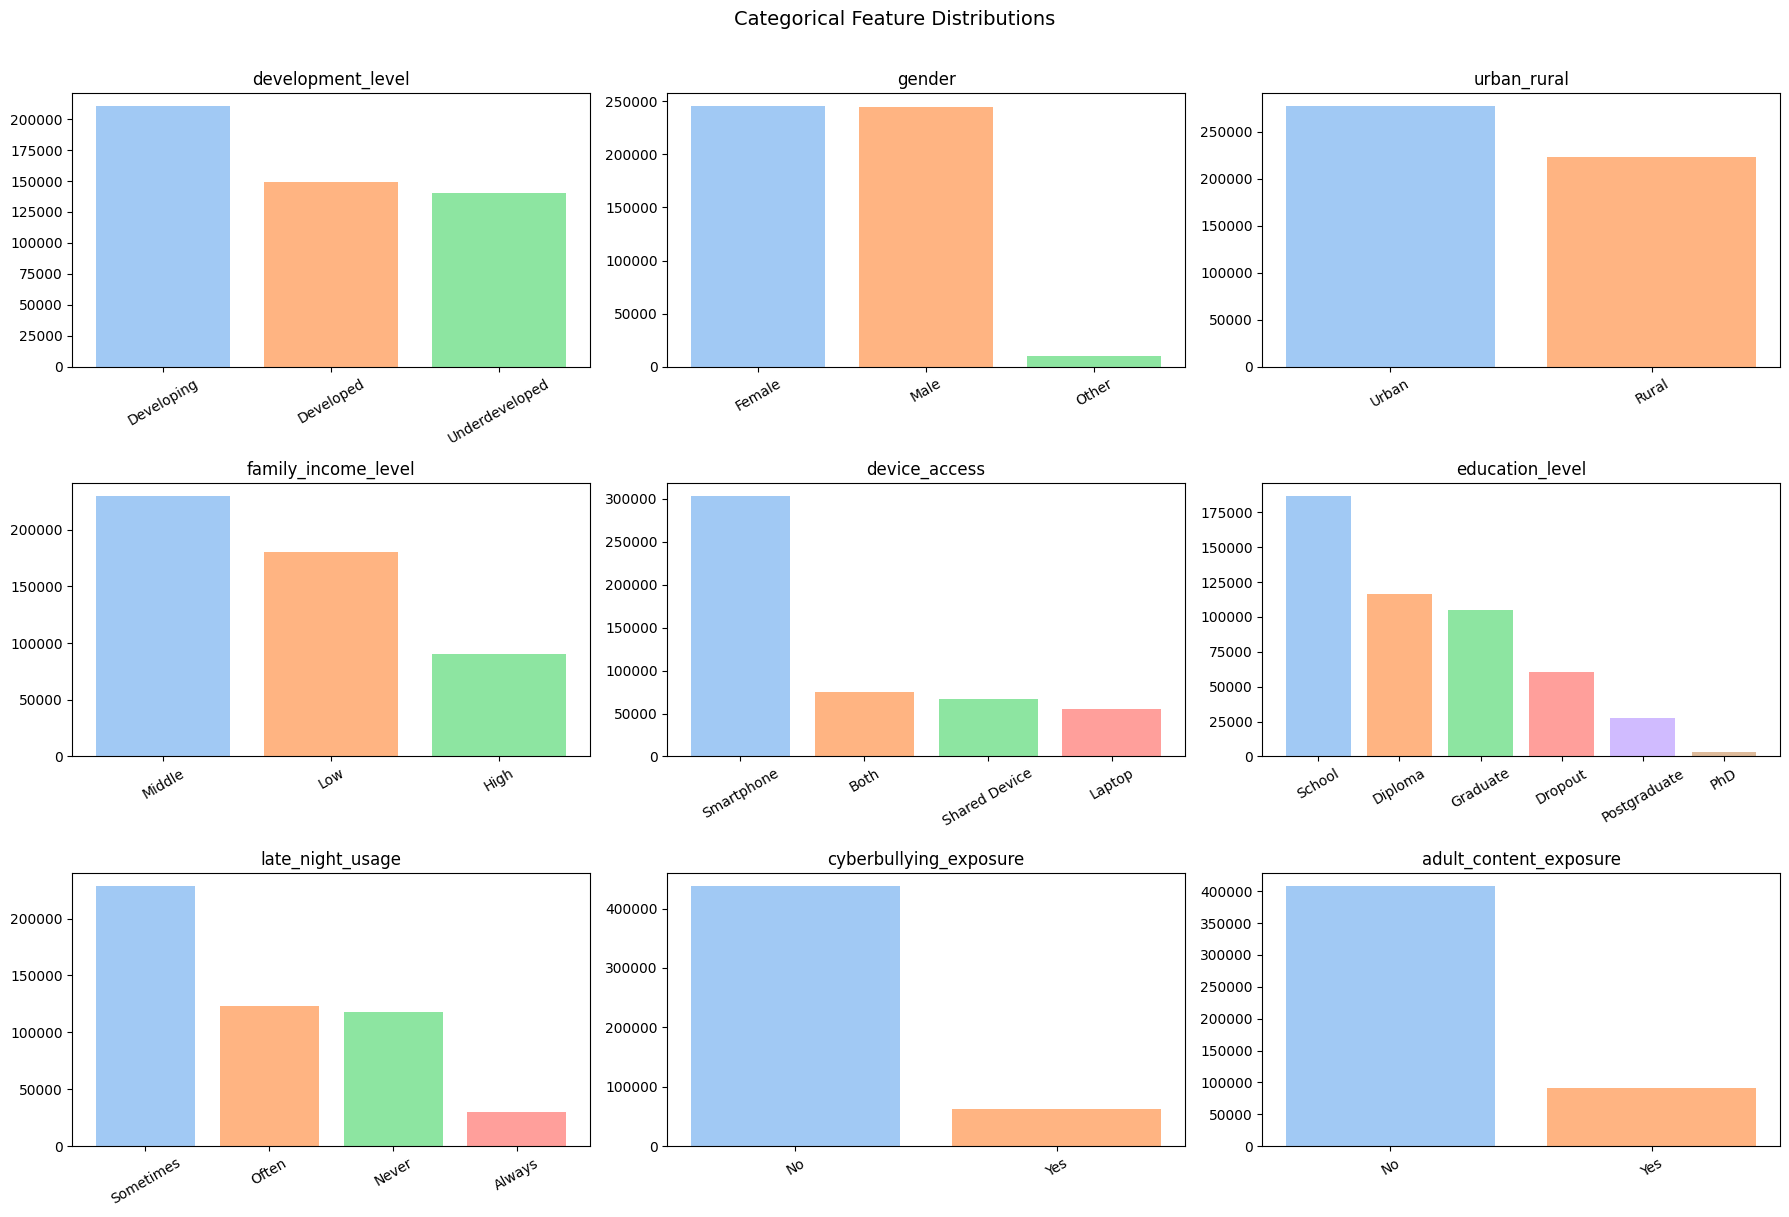

In [63]:
ncols = 3
nrows = (len(cat_cols) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    vc = df[col].value_counts()
    axes[i].bar(vc.index, vc.values, color=sns.color_palette('pastel')[:len(vc)])
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=30)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Categorical Feature Distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

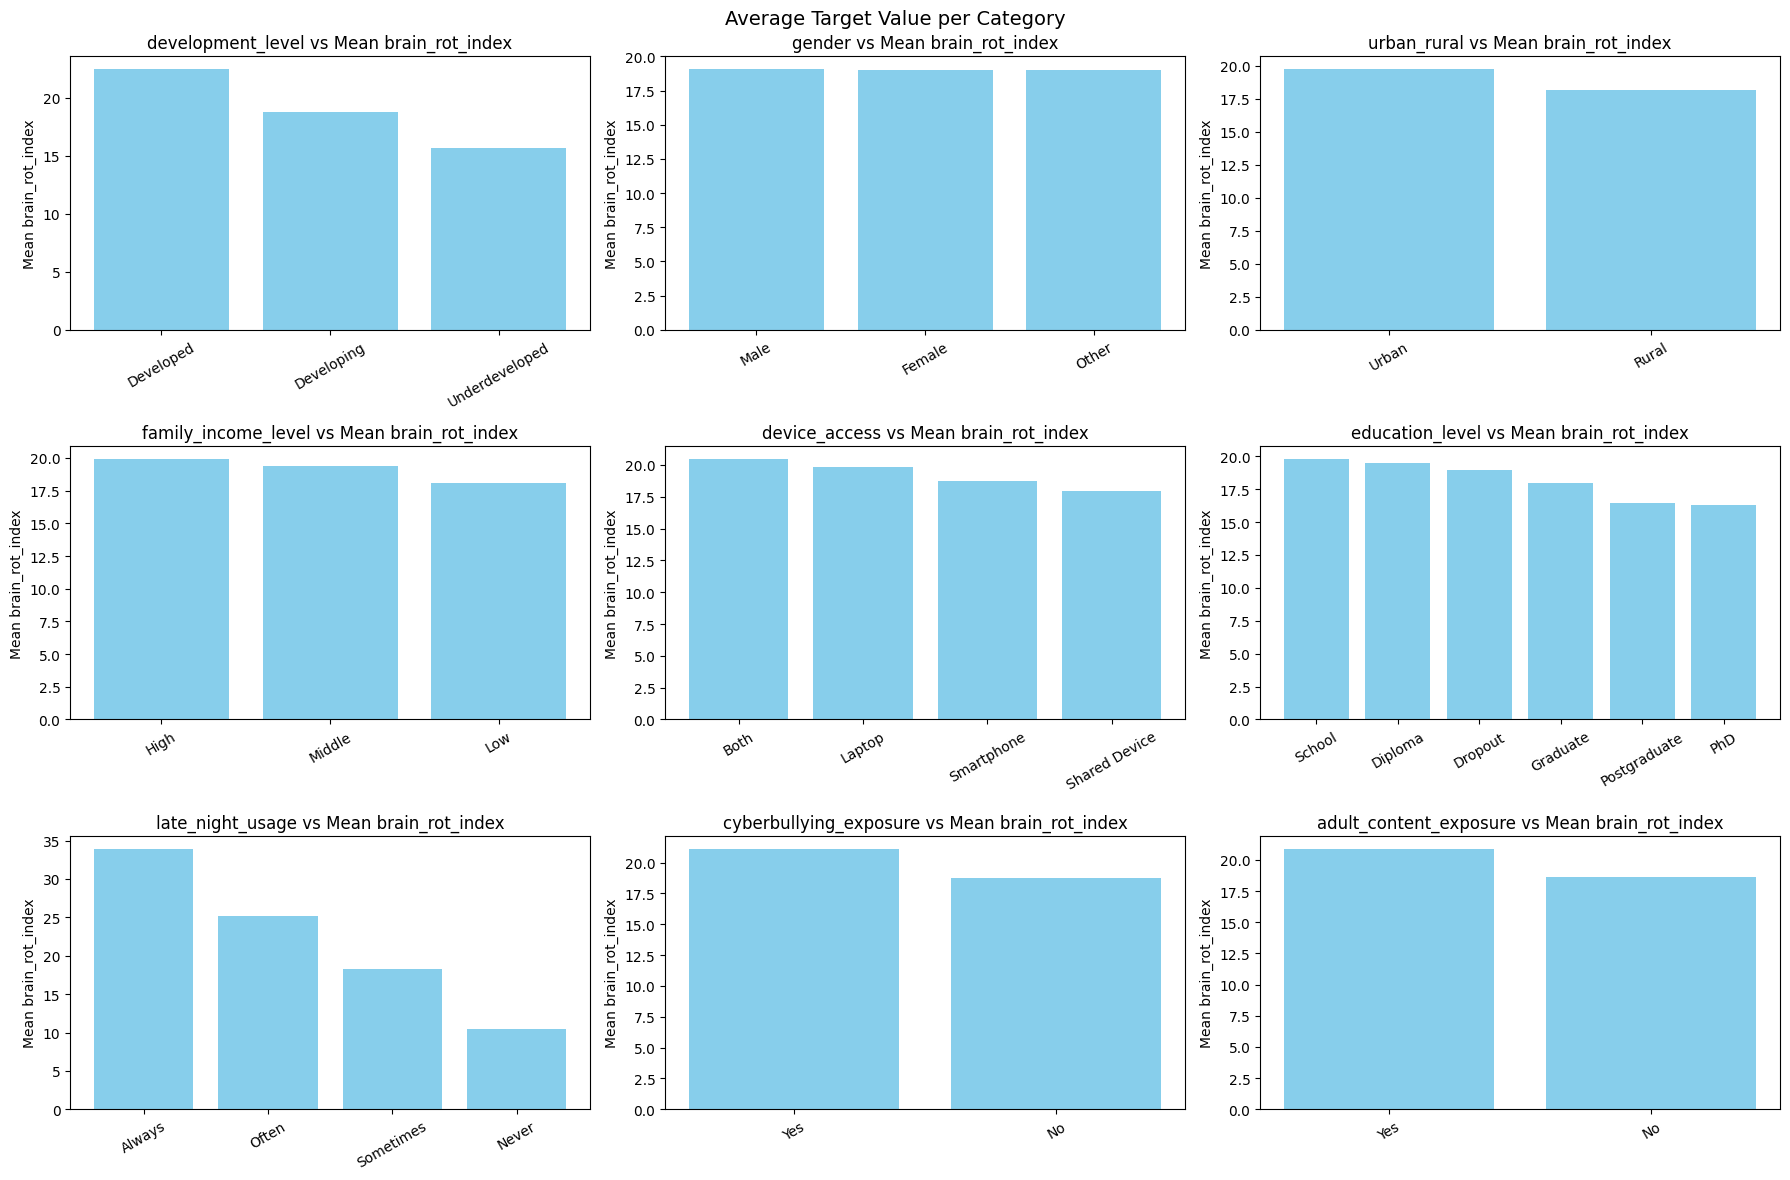

In [ ]:
ncols = 3
nrows = (len(cat_cols) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 4*nrows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(cat_cols):

    target_mean = df.groupby(col)[TARGET].mean().sort_values(ascending=False)

    axes[i].bar(
        target_mean.index.astype(str),
        target_mean.values,
        color='skyblue'
    )

    axes[i].set_title(f'{col} vs Mean {TARGET}')
    axes[i].set_ylabel(f'Mean {TARGET}')
    axes[i].tick_params(axis='x', rotation=30)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Average Target Value per Category', fontsize=14)
plt.tight_layout()
plt.show()

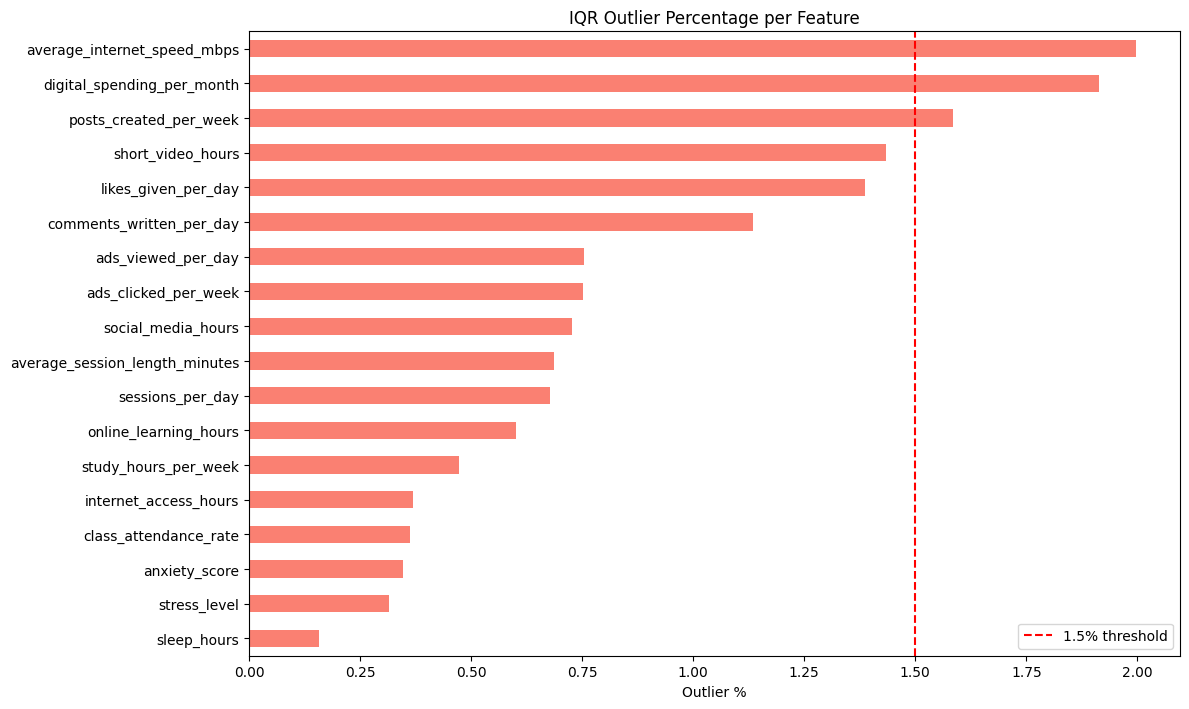


Columns with >1.5% outliers (→ capped):
average_internet_speed_mbps    2.00
digital_spending_per_month     1.91
posts_created_per_week         1.59
dtype: float64

Columns with ≤1.5% outliers (→ rows dropped):
short_video_hours                 1.43
likes_given_per_day               1.39
comments_written_per_day          1.13
ads_viewed_per_day                0.75
ads_clicked_per_week              0.75
social_media_hours                0.73
average_session_length_minutes    0.69
sessions_per_day                  0.68
online_learning_hours             0.60
study_hours_per_week              0.47
internet_access_hours             0.37
class_attendance_rate             0.36
anxiety_score                     0.35
stress_level                      0.32
sleep_hours                       0.16
dtype: float64


In [65]:
def iqr_outlier_pct(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return ((series < q1 - 1.5 * iqr) | (series > q3 + 1.5 * iqr)).sum() / len(series) * 100

outlier_pcts = {col: iqr_outlier_pct(df[col].dropna()) for col in plot_cols}
outlier_series = pd.Series(outlier_pcts).sort_values(ascending=False)
outlier_series = outlier_series[outlier_series > 0]

fig, ax = plt.subplots(figsize=(12, max(4, len(outlier_series) * 0.4)))
outlier_series.sort_values().plot(kind='barh', ax=ax, color='salmon')
ax.axvline(x=1.5, color='red', linestyle='--', label='1.5% threshold')
ax.set_xlabel('Outlier %')
ax.set_title('IQR Outlier Percentage per Feature')
ax.legend()
plt.tight_layout()
plt.show()

print("\nColumns with >1.5% outliers (→ capped):")
print(outlier_series[outlier_series > 1.5].round(2))
print("\nColumns with ≤1.5% outliers (→ rows dropped):")
print(outlier_series[outlier_series <= 1.5].round(2))

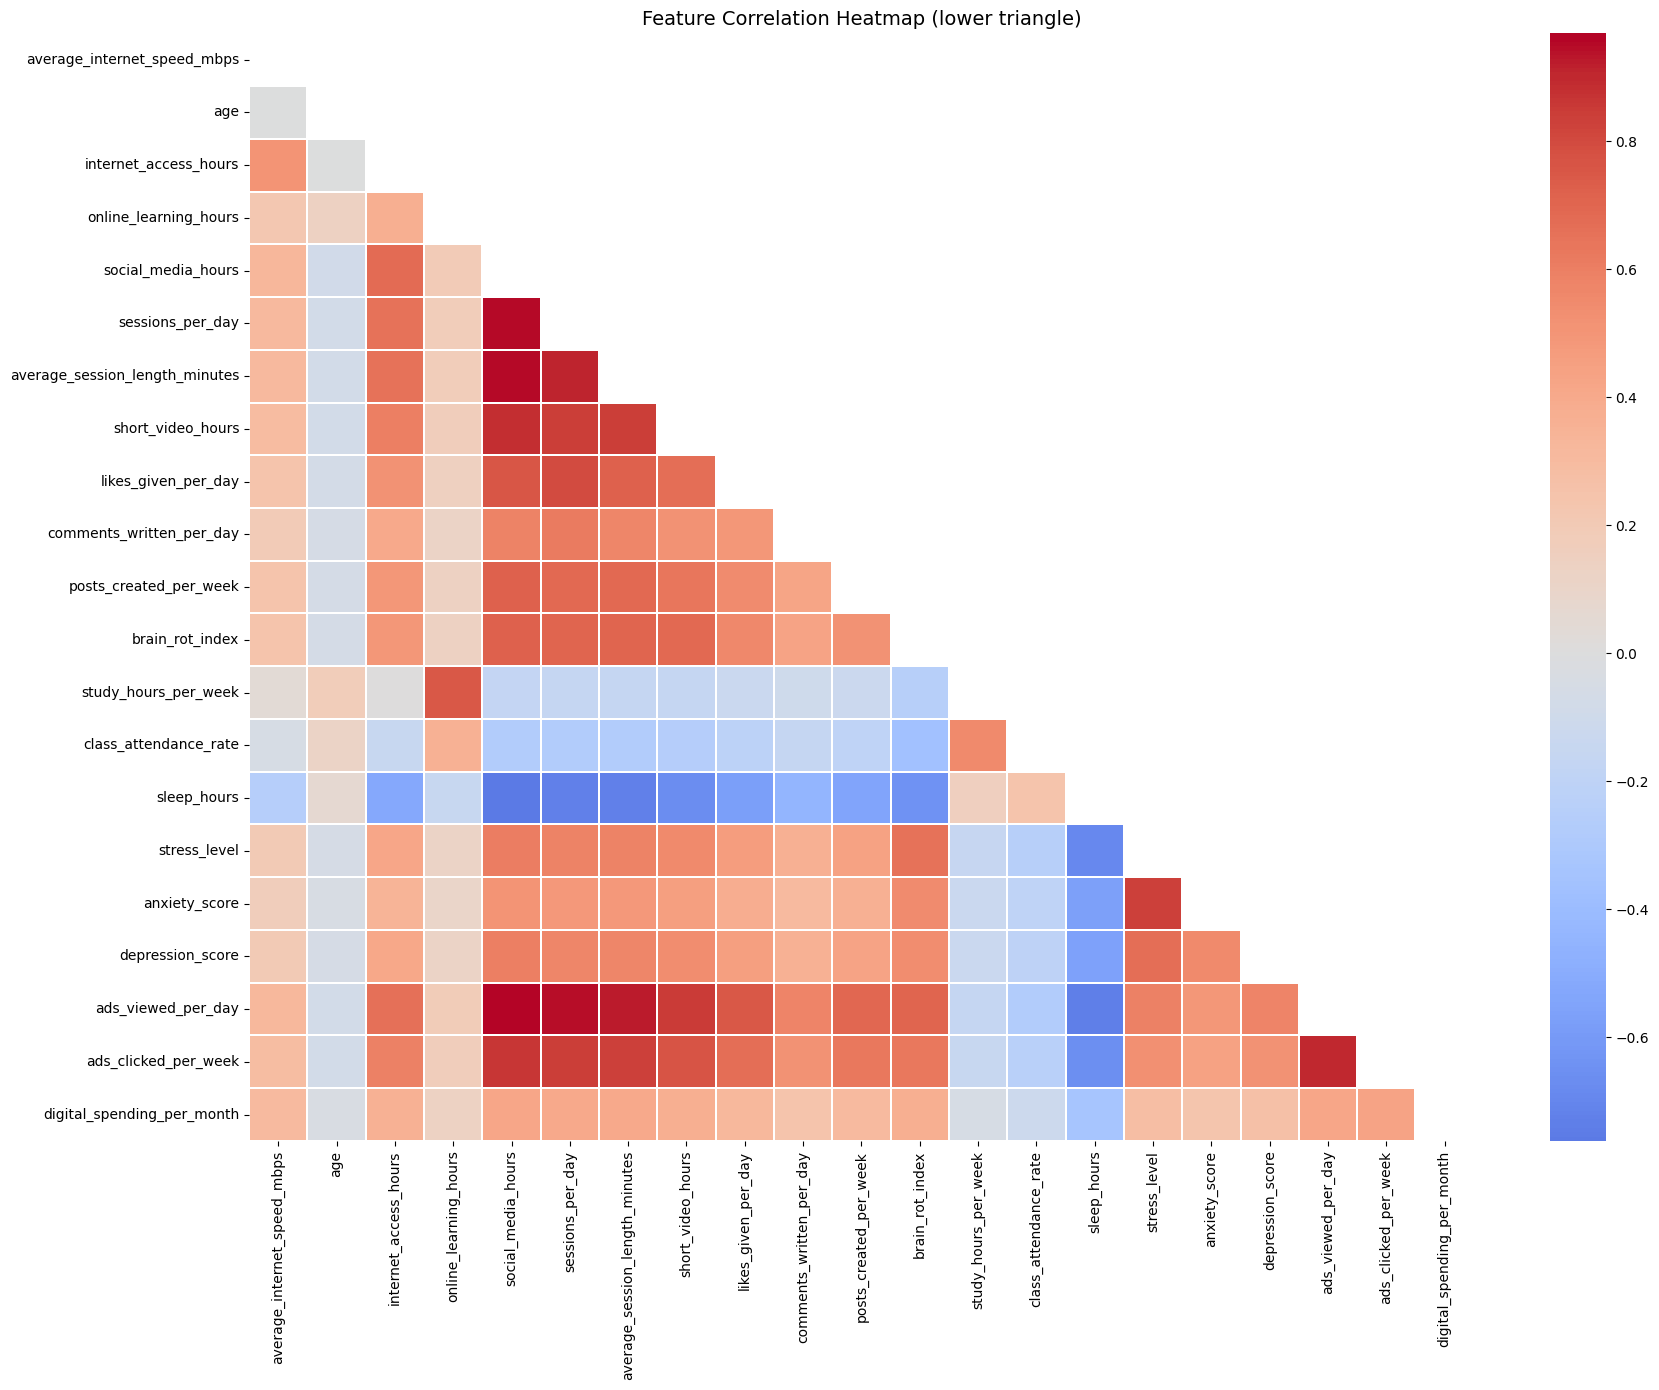

In [66]:
# Full correlation heatmap
corr_cols = [c for c in num_cols if c != 'student_id']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(18, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='coolwarm',
            center=0, linewidths=0.3, ax=ax)
ax.set_title('Feature Correlation Heatmap (lower triangle)', fontsize=14)
plt.tight_layout()
plt.show()

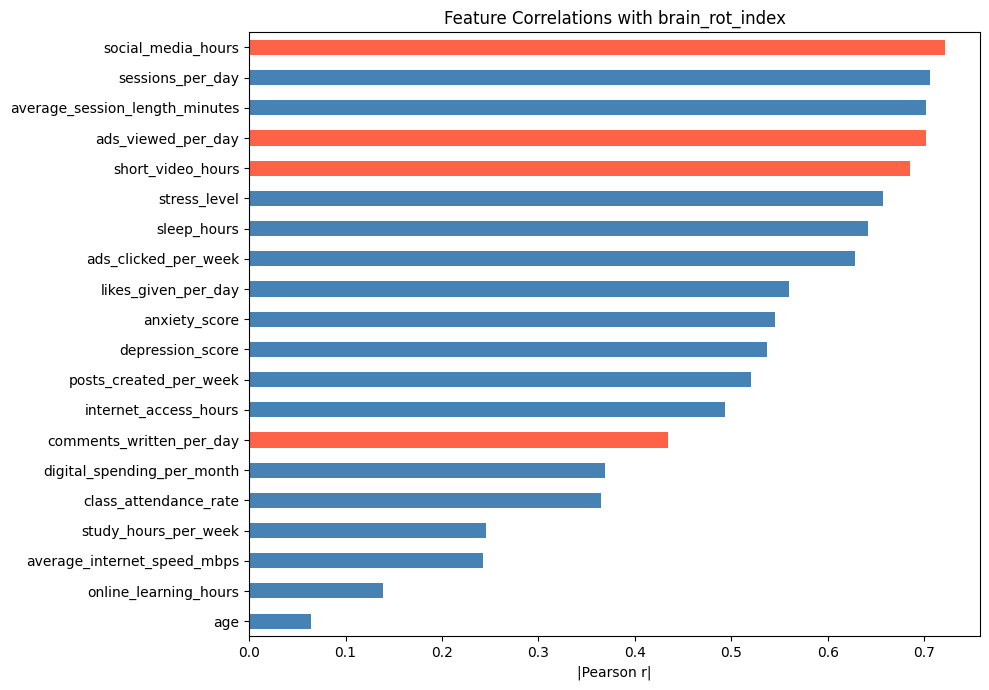


Top 10 features correlated with target:
social_media_hours                0.7218
sessions_per_day                  0.7056
average_session_length_minutes    0.7024
ads_viewed_per_day                0.7023
short_video_hours                 0.6858
stress_level                      0.6573
sleep_hours                       0.6422
ads_clicked_per_week              0.6287
likes_given_per_day               0.5600
anxiety_score                     0.5450
Name: brain_rot_index, dtype: float64


In [ ]:
if TARGET in corr_matrix.columns:
    target_corr = corr_matrix[TARGET].drop(TARGET).abs().sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(10, max(5, len(target_corr) * 0.35)))
    target_corr.sort_values().plot(kind='barh', ax=ax,
                                    color=['steelblue' if v >= 0 else 'tomato'
                                           for v in corr_matrix[TARGET].drop(TARGET)
                                                                        .loc[target_corr.index]])
    ax.set_xlabel('|Pearson r|')
    ax.set_title(f'Feature Correlations with {TARGET}')
    plt.tight_layout()
    plt.show()

    print("\nTop 10 features correlated with target:")
    print(target_corr.head(10).round(4))